# Week 4: Learning Query-Conditioned Evidence Allocation (QCCA)
**Project:** CS787 Generative AI — Query-Conditioned Context Allocator  
**Parent Framework:** SARA — Selective and Adaptive Retrieval-augmented Generation with Context Compression  
**Benchmark:** QASPER Development Split (Paper-disjoint from training)  
**Evaluation Protocol:** 5-Fold GroupKFold Cross-Validation by Paper ID (`paper_id`)  
**Frozen Contract:** Action space $\mathcal{K}_{\text{alloc}} = \{2, 4, 5, 6, 8\}$, Target tolerance $\epsilon^* = 0.01$

---
## Mode Configuration (Smoke Test vs Full Complete Evaluation)
Set `RUN_SMOKE_TEST = False` for the complete 231-question scientific run, or `True` for a rapid 3-question smoke test.


In [1]:
# Configuration Toggle
RUN_SMOKE_TEST = False   # Set to True for fast 3-question smoke test, False for complete 231-question run
SMOKE_TEST_LIMIT = 3

print(f"Execution Mode: {'SMOKE TEST (limit = ' + str(SMOKE_TEST_LIMIT) + ' questions)' if RUN_SMOKE_TEST else 'COMPLETE FULL EVALUATION (231 questions)'}")



Execution Mode: COMPLETE FULL EVALUATION (231 questions)


## 1. Environment & Frozen Artifact Verification
Verify that frozen Week-2 fixed-$k$ response matrices and Week-3 oracle targets are intact.


In [2]:
import sys, os, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cwd = Path.cwd().resolve()
if (cwd / "results").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "results").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd.parent.parent / "results").exists():
    PROJECT_ROOT = cwd.parent.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Verify frozen Week 2 and Week 3 artifacts
w2_matrix_path = PROJECT_ROOT / "results/week2/processed/dev_per_query_k_matrix.csv"
w2_feat_path = PROJECT_ROOT / "results/week2/processed/dev_retrieval_features.jsonl"
w3_targets_path = PROJECT_ROOT / "results/week3/processed/epsilon_oracle_all.csv"

assert w2_matrix_path.exists(), f"Week 2 response matrix missing at {w2_matrix_path}!"
assert w2_feat_path.exists(), f"Week 2 features missing at {w2_feat_path}!"
assert w3_targets_path.exists(), f"Week 3 targets missing at {w3_targets_path}!"

print("✓ All frozen source artifacts verified at PROJECT_ROOT:", PROJECT_ROOT)



✓ All frozen source artifacts verified at PROJECT_ROOT: /home/gunavenkat/Downloads/CS787-RAG-Project


## 2. Load Pre-generation Retrieval Features
Load the immutable pre-generation retrieval features from Week 2 and audit for forbidden data leakage.


In [3]:
from src.week4.features import load_retrieval_features, audit_for_leakage

df_features = load_retrieval_features(
    features_path=str(w2_feat_path),
    smoke_test=RUN_SMOKE_TEST,
    smoke_limit=SMOKE_TEST_LIMIT
)

print(f"Loaded features table shape: {df_features.shape}")
print(f"Unique questions: {df_features['question_id'].nunique()}, Unique papers: {df_features['paper_id'].nunique()}")
display(df_features.head())



Loaded features table shape: (231, 8)
Unique questions: 231, Unique papers: 86


,question_id,paper_id,rho_1,delta_12,entropy,entropy_normalized,query_token_length,n_high
0,1912,638,1.000000,1.000000,0.000000,0.000000,8,1
1,2201,798,0.199186,0.371415,2.235207,0.970738,13,1
2,883,254,0.344720,0.325243,1.820532,0.790647,4,1
3,884,254,1.000000,1.000000,0.000000,0.000000,4,1
4,104,28,0.218956,0.179344,2.145187,0.931643,5,2


## 3. Load Frozen Week-3 Targets ($\epsilon^* = 0.01$)
Filter targets to the frozen development operating point $\epsilon^* = 0.01$ over deployable action space $\mathcal{K}_{\text{alloc}} = \{2, 4, 5, 6, 8\}$.


In [4]:
from src.week4.targets import load_epsilon_targets, prepare_training_dataset

df_targets = load_epsilon_targets(
    targets_path=str(w3_targets_path),
    epsilon_star=0.01,
    k_alloc=[2, 4, 5, 6, 8]
)

df_data = prepare_training_dataset(df_features, df_targets)
print(f"Prepared combined dataset: {len(df_data)} rows across {df_data['paper_id'].nunique()} papers")
display(df_data[['question_id', 'paper_id', 'target_k', 'selected_f1', 'reference_f1_alloc', 'f1_regret']].head())



Prepared combined dataset: 231 rows across 86 papers


,question_id,paper_id,target_k,selected_f1,reference_f1_alloc,f1_regret
0,1912,638,8,0.5,0.5,0.0
1,2201,798,2,0.8,0.8,0.0
2,883,254,6,1.0,1.0,0.0
3,884,254,2,1.0,1.0,0.0
4,104,28,2,0.0,0.0,0.0


## 4. Target Distribution Analysis
Inspect class balance across $\mathcal{K}_{\text{alloc}} = \{2, 4, 5, 6, 8\}$.


=== Frozen Target Distribution (epsilon* = 0.01) ===


,Count,Percentage (%)
target_k,,
2,132,57.14
4,40,17.32
5,17,7.36
6,19,8.23
8,23,9.96


/tmp/ipykernel_676357/3022105278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, palette="Blues_d")


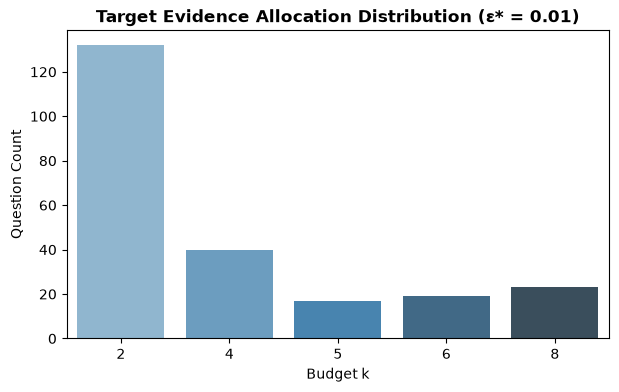

In [5]:
target_counts = df_data['target_k'].value_counts().sort_index()
target_pcts = (target_counts / len(df_data) * 100).round(2)
dist_df = pd.DataFrame({"Count": target_counts, "Percentage (%)": target_pcts})
print("=== Frozen Target Distribution (epsilon* = 0.01) ===")
display(dist_df)

plt.figure(figsize=(7, 4))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, palette="Blues_d")
plt.title("Target Evidence Allocation Distribution (ε* = 0.01)", fontweight="bold")
plt.xlabel("Budget k")
plt.ylabel("Question Count")
plt.show()



## 5. GroupKFold Cross-Validation Setup
Define 5-fold cross-validation partitioned strictly by `paper_id` to guarantee zero cross-question paper leakage.


In [6]:
from src.week4.cross_validation import run_grouped_cross_validation, verify_oof_integrity

FEATURE_COLS = ["rho_1", "delta_12", "entropy", "entropy_normalized", "query_token_length", "n_high"]

df_oof, cv_meta = run_grouped_cross_validation(
    df_data=df_data,
    feature_cols=FEATURE_COLS,
    target_col="target_k",
    group_col="paper_id",
    n_splits=5,
    random_state=42,
    logreg_C=1.0,
    tree_depth=3
)

print(f"Completed {cv_meta['n_splits']}-Fold GroupKFold Cross-Validation.")
for fold_info in cv_meta['folds']:
    print(f"Fold {fold_info['fold']}: Train Papers={fold_info['n_train_papers']}, Val Papers={fold_info['n_val_papers']}, Overlap={fold_info['paper_overlap_count']}")

verify_oof_integrity(df_oof, expected_count=len(df_data), k_alloc=[2, 4, 5, 6, 8])



Completed 5-Fold GroupKFold Cross-Validation.
Fold 0: Train Papers=69, Val Papers=17, Overlap=0
Fold 1: Train Papers=69, Val Papers=17, Overlap=0
Fold 2: Train Papers=69, Val Papers=17, Overlap=0
Fold 3: Train Papers=69, Val Papers=17, Overlap=0
Fold 4: Train Papers=68, Val Papers=18, Overlap=0


## 6. Model Evaluation on Out-of-Fold Predictions
Evaluate all systems using the frozen Week-2 matrix lookup. Compare QCCA models against static baselines, random control, and oracles.


In [7]:
from src.week4.evaluation import FrozenResponseSurfaceLookup, evaluate_allocator_predictions

lookup = FrozenResponseSurfaceLookup(str(w2_matrix_path))

# Populate synthetic baseline columns
k_alloc = [2, 4, 5, 6, 8]
df_oof["pred_k_static_5"] = 5
df_oof["pred_k_static_8"] = 8
df_oof["pred_k_static_best"] = 8
np.random.seed(42)
df_oof["pred_k_random"] = np.random.choice(k_alloc, size=len(df_oof))
df_oof["pred_k_quality_oracle"] = [min(k_alloc, key=lambda k: (-lookup.get_f1(str(r["question_id"]), k), k)) for _, r in df_oof.iterrows()]

systems = [
    ("Static k=5", "static_5"),
    ("Static k=8 (Best Static)", "static_8"),
    ("Random Allocation", "random"),
    ("QCCA-Rule", "pred_k_rule"),
    ("QCCA-LogReg", "pred_k_logreg"),
    ("QCCA-Tree", "pred_k_tree"),
    ("Epsilon Oracle (ε=0.01)", "target_k"),
    ("Quality Oracle", "quality_oracle")
]

records = []
for label, col_key in systems:
    col_name = col_key if col_key.startswith("pred_k_") or col_key == "target_k" else f"pred_k_{col_key}"
    metrics = evaluate_allocator_predictions(df_oof, col_name, lookup, target_col="target_k")
    records.append({
        "System": label,
        "Mean F1": metrics["mean_f1"],
        "Mean k": metrics["mean_k"],
        "Context Tokens": metrics["mean_context_tokens"],
        "Context Reduct. (%)": metrics["context_reduction_pct_vs_k8"],
        "Mean Regret": metrics["mean_epsilon_regret"],
        "Target Accuracy": metrics["target_accuracy"],
        "Headroom Recovered (%)": metrics["oracle_headroom_recovered_pct"]
    })

df_model_comparison = pd.DataFrame(records)
print("=== Table 1: Model Development Performance ===")
display(df_model_comparison)



=== Table 1: Model Development Performance ===


,System,Mean F1,Mean k,Context Tokens,Context Reduct. (%),Mean Regret,Target Accuracy,Headroom Recovered (%)
0,Static k=5,0.3629,5.00,1157.0,34.21,0.1266,0.0736,-34.00
1,Static k=8 (Best Static),0.3950,8.00,1758.5,0.00,0.0945,0.0996,0.00
2,Random Allocation,0.3709,4.90,1131.0,35.68,0.1185,0.2035,-25.45
3,QCCA-Rule,0.3286,3.56,854.4,51.41,0.1608,0.3247,-70.26
4,QCCA-LogReg,0.3034,2.03,539.8,69.30,0.1860,0.5671,-96.96
5,QCCA-Tree,0.3282,2.66,671.0,61.84,0.1612,0.4892,-70.70
6,Epsilon Oracle (ε=0.01),0.4894,3.49,841.3,52.16,0.0000,1.0000,99.88
7,Quality Oracle,0.4895,3.53,848.4,51.75,0.0000,0.9827,100.00


## 7. Oracle Headroom Recovery Analysis
Quantify how much of the +0.0945 F1 oracle headroom over static $k=8$ is recovered by each allocation system.


In [8]:
static_f1 = df_model_comparison[df_model_comparison["System"].str.contains("Best Static")]["Mean F1"].iloc[0]
oracle_f1 = df_model_comparison[df_model_comparison["System"] == "Quality Oracle"]["Mean F1"].iloc[0]
total_headroom = oracle_f1 - static_f1

headroom_rows = []
for sys_name in ["QCCA-Rule", "QCCA-LogReg", "QCCA-Tree", "Random Allocation", "Epsilon Oracle (ε=0.01)"]:
    m_f1 = df_model_comparison[df_model_comparison["System"] == sys_name]["Mean F1"].iloc[0]
    gain = m_f1 - static_f1
    rec = (gain / total_headroom * 100.0) if total_headroom > 1e-6 else 0.0
    headroom_rows.append({
        "System": sys_name,
        "Mean F1": m_f1,
        "Static k=8 F1": static_f1,
        "Quality Oracle F1": oracle_f1,
        "Gain vs Static": round(gain, 4),
        "Oracle Headroom Recovered (%)": round(rec, 2)
    })

df_headroom = pd.DataFrame(headroom_rows)
print("=== Table 2: Headroom Recovery ===")
display(df_headroom)



=== Table 2: Headroom Recovery ===


,System,Mean F1,Static k=8 F1,Quality Oracle F1,Gain vs Static,Oracle Headroom Recovered (%)
0,QCCA-Rule,0.3286,0.395,0.4895,-0.0664,-70.26
1,QCCA-LogReg,0.3034,0.395,0.4895,-0.0916,-96.93
2,QCCA-Tree,0.3282,0.395,0.4895,-0.0668,-70.69
3,Random Allocation,0.3709,0.395,0.4895,-0.0241,-25.50
4,Epsilon Oracle (ε=0.01),0.4894,0.395,0.4895,0.0944,99.89


## 8. Feature Set Ablation & Leave-One-Feature-Out
Assess whether concentration-only features are sufficient vs full retrieval-side signals, and evaluate sensitivity when removing individual features.


In [9]:
from src.week4.feature_ablation import run_feature_set_ablation, run_leave_one_feature_out

feature_sets = {
    "concentration_only": ["rho_1", "delta_12", "entropy_normalized", "n_high"],
    "full": FEATURE_COLS
}

df_ablation = run_feature_set_ablation(df_data, feature_sets, lookup, n_splits=cv_meta['n_splits'])
print("=== Table 3: Feature Set Ablation ===")
display(df_ablation)

df_lofo = run_leave_one_feature_out(df_data, FEATURE_COLS, lookup, n_splits=cv_meta['n_splits'])
print("=== Table 4: Leave-One-Feature-Out Sensitivity ===")
display(df_lofo)



=== Table 3: Feature Set Ablation ===


,feature_set,feature_count,features,mean_f1,mean_k,mean_context_tokens,context_reduction_pct_vs_k8,target_accuracy,mean_epsilon_regret,oracle_headroom_recovered_pct
0,concentration_only,4,"rho_1, delta_12, entropy_normalized, n_high",0.3034,2.03,539.8,69.3,0.5671,0.186,-96.96
1,full,6,"rho_1, delta_12, entropy, entropy_normalized, ...",0.3034,2.03,539.8,69.3,0.5671,0.186,-96.96


=== Table 4: Leave-One-Feature-Out Sensitivity ===


,removed_feature,remaining_features_count,mean_f1,mean_k,context_tokens,target_accuracy,delta_f1,delta_mean_k,delta_context_tokens,delta_target_accuracy
0,rho_1,5,0.3034,2.03,539.8,0.5671,0.0,0.0,0.0,0.0
1,delta_12,5,0.3034,2.03,539.8,0.5671,0.0,0.0,0.0,0.0
2,entropy,5,0.3034,2.03,539.8,0.5671,0.0,0.0,0.0,0.0
3,entropy_normalized,5,0.3034,2.03,539.8,0.5671,0.0,0.0,0.0,0.0
4,query_token_length,5,0.3034,2.03,539.8,0.5671,0.0,0.0,0.0,0.0
5,n_high,5,0.3034,2.03,539.8,0.5671,0.0,0.0,0.0,0.0


## 9. Feature Importance
Extract standardized regression coefficients and tree feature importances.


=== Table 5: Feature Importance (Logistic Regression) ===


,feature,model,importance_metric,importance_value,coef_class_2,coef_class_4,coef_class_5,coef_class_6,coef_class_8
0,rho_1,LogisticRegression,mean_abs_coefficient,0.357253,0.357205,0.235951,-0.666667,-0.226466,0.299977
1,n_high,LogisticRegression,mean_abs_coefficient,0.248205,0.195750,-0.107155,-0.513358,0.413519,0.011244
2,delta_12,LogisticRegression,mean_abs_coefficient,0.200460,-0.233408,-0.267742,0.101639,0.380541,0.018970
3,query_token_length,LogisticRegression,mean_abs_coefficient,0.113589,0.068411,-0.101888,0.034725,-0.182085,0.180838
4,entropy,LogisticRegression,mean_abs_coefficient,0.093428,-0.048573,0.089749,0.143822,-0.108915,-0.076084
5,entropy_normalized,LogisticRegression,mean_abs_coefficient,0.093424,-0.048560,0.089742,0.143819,-0.108914,-0.076086


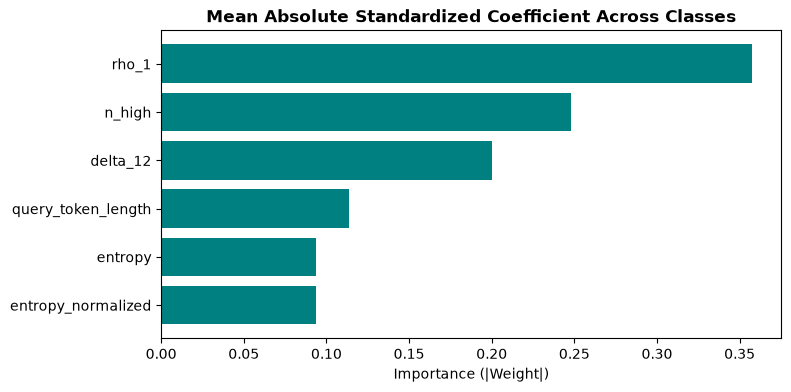

In [10]:
from src.week4.qcca_models import create_logistic_regression_pipeline, extract_feature_importance

logreg_full = create_logistic_regression_pipeline(C=1.0, random_state=42)
logreg_full.fit(df_data[FEATURE_COLS], df_data["target_k"])

df_importance = extract_feature_importance(logreg_full, FEATURE_COLS)
print("=== Table 5: Feature Importance (Logistic Regression) ===")
display(df_importance)

plt.figure(figsize=(8, 4))
plt.barh(df_importance["feature"], df_importance["importance_value"], color="teal")
plt.title("Mean Absolute Standardized Coefficient Across Classes", fontweight="bold")
plt.xlabel("Importance (|Weight|)")
plt.gca().invert_yaxis()
plt.show()



## 10. Pareto Frontier Analysis (Context Cost vs F1 Quality)
Identify Pareto non-dominated operating points in (Context Prompt Tokens, Mean Token F1) space.


=== Pareto Frontier Analysis ===


,system,mean_f1,mean_context_tokens,is_pareto_optimal
0,Static k=2,0.3038,534.5,True
1,QCCA-LogReg,0.3034,539.8,False
2,QCCA-Tree,0.3282,671.0,True
3,Epsilon Oracle,0.4894,841.3,True
4,Quality Oracle,0.4895,848.4,True
5,QCCA-Rule,0.3286,854.4,False
6,Static k=4,0.3596,946.1,False
7,Random Allocation,0.3709,1131.0,False
8,Static k=5,0.3629,1157.0,False
9,Static k=6,0.3857,1359.1,False


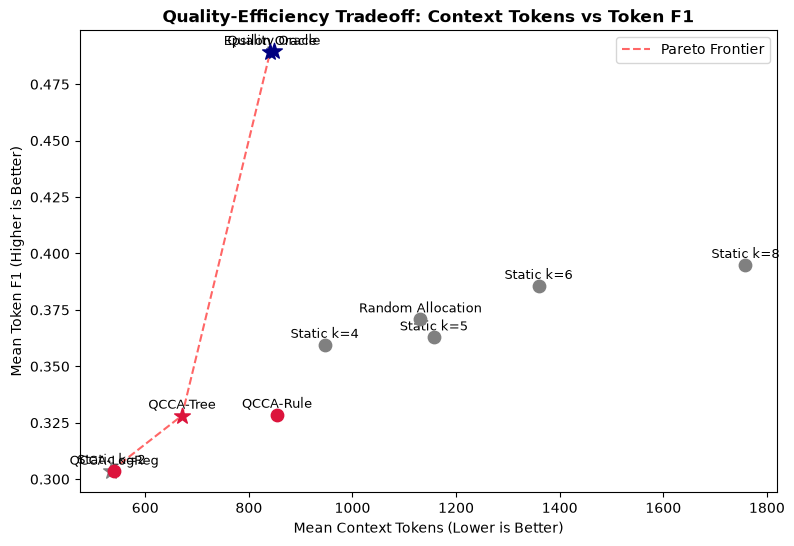

In [11]:
from src.week4.pareto import compute_pareto_frontier

pareto_data = [
    {"system": "Static k=2", "mean_f1": 0.3038, "mean_context_tokens": 534.5},
    {"system": "Static k=4", "mean_f1": 0.3596, "mean_context_tokens": 946.1},
    {"system": "Static k=5", "mean_f1": 0.3629, "mean_context_tokens": 1157.0},
    {"system": "Static k=6", "mean_f1": 0.3857, "mean_context_tokens": 1359.1},
    {"system": "Static k=8", "mean_f1": 0.3950, "mean_context_tokens": 1758.5},
    {"system": "Random Allocation", "mean_f1": df_model_comparison[df_model_comparison["System"] == "Random Allocation"]["Mean F1"].iloc[0], "mean_context_tokens": df_model_comparison[df_model_comparison["System"] == "Random Allocation"]["Context Tokens"].iloc[0]},
    {"system": "QCCA-Rule", "mean_f1": df_model_comparison[df_model_comparison["System"] == "QCCA-Rule"]["Mean F1"].iloc[0], "mean_context_tokens": df_model_comparison[df_model_comparison["System"] == "QCCA-Rule"]["Context Tokens"].iloc[0]},
    {"system": "QCCA-LogReg", "mean_f1": df_model_comparison[df_model_comparison["System"] == "QCCA-LogReg"]["Mean F1"].iloc[0], "mean_context_tokens": df_model_comparison[df_model_comparison["System"] == "QCCA-LogReg"]["Context Tokens"].iloc[0]},
    {"system": "QCCA-Tree", "mean_f1": df_model_comparison[df_model_comparison["System"] == "QCCA-Tree"]["Mean F1"].iloc[0], "mean_context_tokens": df_model_comparison[df_model_comparison["System"] == "QCCA-Tree"]["Context Tokens"].iloc[0]},
    {"system": "Epsilon Oracle", "mean_f1": df_model_comparison[df_model_comparison["System"] == "Epsilon Oracle (ε=0.01)"]["Mean F1"].iloc[0], "mean_context_tokens": df_model_comparison[df_model_comparison["System"] == "Epsilon Oracle (ε=0.01)"]["Context Tokens"].iloc[0]},
    {"system": "Quality Oracle", "mean_f1": df_model_comparison[df_model_comparison["System"] == "Quality Oracle"]["Mean F1"].iloc[0], "mean_context_tokens": df_model_comparison[df_model_comparison["System"] == "Quality Oracle"]["Context Tokens"].iloc[0]}
]

df_pareto = compute_pareto_frontier(pd.DataFrame(pareto_data))
print("=== Pareto Frontier Analysis ===")
display(df_pareto)

plt.figure(figsize=(9, 6))
for _, r in df_pareto.iterrows():
    is_opt = r["is_pareto_optimal"]
    color = "crimson" if "QCCA" in r["system"] else ("navy" if "Oracle" in r["system"] else "gray")
    marker = "*" if is_opt else "o"
    size = 140 if is_opt else 80
    plt.scatter(r["mean_context_tokens"], r["mean_f1"], color=color, marker=marker, s=size, zorder=5)
    plt.annotate(r["system"], (r["mean_context_tokens"], r["mean_f1"] + 0.003), fontsize=9, ha="center")

opt_pts = df_pareto[df_pareto["is_pareto_optimal"]].sort_values("mean_context_tokens")
plt.plot(opt_pts["mean_context_tokens"], opt_pts["mean_f1"], "r--", alpha=0.6, label="Pareto Frontier")
plt.title("Quality-Efficiency Tradeoff: Context Tokens vs Token F1", fontweight="bold")
plt.xlabel("Mean Context Tokens (Lower is Better)")
plt.ylabel("Mean Token F1 (Higher is Better)")
plt.legend()
plt.show()



## 11. Freeze Decision: NO-GO / FREEZE DEFERRED
**Status:** Scientific freeze of QCCA-Learned or QCCA-Rule is **explicitly deferred**.
Before any Week-5 freeze, additional rigorous analyses are performed below:
1. Random Baseline 1,000-seed empirical validation
2. Pre-specified Logistic Regression $C$-sensitivity ($C \in \{0.01, 0.1, 1.0, 10.0\}$) for standard and balanced weights
3. Utility-aware allocation policy using training-fold quality/cost trade-offs
4. Updated Pareto dominance analysis and feature insufficiency diagnosis.
No `qcca_freeze_spec.json` is generated at this stage.


## 12. Random Baseline Validation (1,000 Seeds)
We validate the uniform random baseline and evaluate a target-frequency-matched baseline over 1,000 empirical draws.


In [12]:
from src.week4.additional_analysis import validate_random_baselines

# Run 1,000 seeds (or 10 seeds if smoke testing)
n_seeds = 10 if RUN_SMOKE_TEST else 1000
random_results = validate_random_baselines(df_data, lookup, n_seeds=n_seeds)

print(f"=== Random Baseline Validation ({n_seeds} seeds) ===")
print("\n--- Uniform Random Allocation ---")
for k, v in random_results["uniform_random"].items():
    print(f"  {k}: {v}")
print("\n--- Target-Frequency Matched Random Allocation ---")
for k, v in random_results["target_frequency_matched_random"].items():
    print(f"  {k}: {v}")


2026-09-30 19:11:17,131 [INFO] Running random baseline validation across 1000 seeds...


=== Random Baseline Validation (1000 seeds) ===

--- Uniform Random Allocation ---
  mean_f1: 0.3613111
  std_f1: 0.010792527358779315
  ci95_f1: [0.34038999999999997, 0.3822025]
  mean_k: 4.99986
  std_k: 0.1329841358959782
  mean_context_tokens: 1151.0337
  context_reduction_pct_vs_k8: 34.54474
  mean_epsilon_regret: 0.12811970000000003
  target_accuracy: 0.199858
  allocation_distribution_pct: {2: 20.05, 4: 19.85, 5: 20.0, 6: 20.17, 8: 19.94}

--- Target-Frequency Matched Random Allocation ---
  mean_f1: 0.3336922
  std_f1: 0.01054399730462788
  ci95_f1: [0.31359, 0.3549075]
  mean_k: 3.4920299999999997
  std_k: 0.13297209895312626
  mean_context_tokens: 840.9738000000001
  context_reduction_pct_vs_k8: 52.1766
  mean_epsilon_regret: 0.1557184
  target_accuracy: 0.379728
  allocation_distribution_pct: {2: 57.19, 4: 17.3, 5: 7.31, 6: 8.29, 8: 9.92}


## 13. Logistic Regression Sensitivity Analysis & Confusion Matrices
Pre-specified evaluation of $C \in \{0.01, 0.1, 1.0, 10.0\}$ under standard and balanced class weights.


In [13]:
from src.week4.additional_analysis import evaluate_logreg_c_sensitivity

df_sens, cms = evaluate_logreg_c_sensitivity(df_data, lookup)
cols_display = ["class_weight", "C", "mean_f1", "mean_k", "mean_context_tokens", "context_reduction_pct_vs_k8", "mean_epsilon_regret", "target_accuracy", "over_compression_pct", "under_compression_pct"]
display(df_sens[cols_display])

print("\n=== Balanced LogReg C=1.0 Confusion Matrix (Rows=True Target, Cols=Predicted) ===")
display(pd.DataFrame(cms["balanced_C_1.0"]).fillna(0.0))


2026-09-30 19:11:52,215 [INFO] Running Logistic Regression C-sensitivity across C=[0.01, 0.1, 1.0, 10.0], weights=[None, 'balanced']


,class_weight,C,mean_f1,mean_k,mean_context_tokens,context_reduction_pct_vs_k8,mean_epsilon_regret,target_accuracy,over_compression_pct,under_compression_pct
0,standard,0.01,0.3038,2.00,534.5,69.60,0.1856,0.5714,42.86,0.00
1,standard,0.10,0.3034,2.03,539.8,69.30,0.1860,0.5671,42.86,0.43
2,standard,1.00,0.3034,2.03,539.8,69.30,0.1860,0.5671,42.86,0.43
3,standard,10.00,0.3034,2.03,539.8,69.30,0.1860,0.5671,42.86,0.43
4,balanced,0.01,0.3669,5.30,1214.0,30.96,0.1226,0.1515,17.75,67.10
5,balanced,0.10,0.3658,4.97,1146.7,34.79,0.1236,0.1861,19.91,61.47
6,balanced,1.00,0.3587,4.93,1137.6,35.31,0.1307,0.1732,21.21,61.47
7,balanced,10.00,0.3661,4.97,1145.3,34.87,0.1233,0.1732,20.78,61.90



=== Balanced LogReg C=1.0 Confusion Matrix (Rows=True Target, Cols=Predicted) ===


,2,4,5,6,8
2,0.166667,0.204545,0.234848,0.181818,0.212121
4,0.200000,0.175000,0.400000,0.175000,0.050000
5,0.117647,0.235294,0.411765,0.117647,0.117647
6,0.157895,0.263158,0.315789,0.105263,0.157895
8,0.173913,0.260870,0.304348,0.173913,0.086957


## 14. Utility-Aware Allocation Experiment
Evaluate an out-of-fold utility-aware allocator maximizing $U(q, k) = \hat{F}_1(q, k) - \lambda \cdot \frac{\text{cost}(k)}{\text{cost}(k=8)}$ fitted exclusively on training-fold response surface data.


In [14]:
from src.week4.additional_analysis import evaluate_utility_aware_allocator

df_util = evaluate_utility_aware_allocator(df_data, lookup, lambda_candidates=[0.02, 0.05, 0.10])
display(df_util[["allocator", "lambda", "mean_f1", "mean_k", "mean_context_tokens", "context_reduction_pct_vs_k8", "mean_epsilon_regret", "target_accuracy"]])


2026-09-30 19:11:52,838 [INFO] Running Utility-Aware Allocator across lambda=[0.02, 0.05, 0.1]


,allocator,lambda,mean_f1,mean_k,mean_context_tokens,context_reduction_pct_vs_k8,mean_epsilon_regret,target_accuracy
0,Utility-Aware (λ=0.02),0.02,0.3796,6.78,1513.7,13.92,0.1099,0.0779
1,Utility-Aware (λ=0.05),0.05,0.3627,6.18,1391.9,20.85,0.1268,0.0736
2,Utility-Aware (λ=0.1),0.10,0.3601,5.39,1230.3,30.04,0.1294,0.1212


## 15. Comprehensive Updated Pareto Frontier & Scientific Conclusion
Assess all static baselines, random baselines, classification allocators, and utility allocators in the context token vs Token F1 trade-off space.


In [15]:
all_systems = [
    {"name": "Static k=2", "mean_f1": 0.3038, "mean_context_tokens": 534.5, "type": "static"},
    {"name": "Static k=4", "mean_f1": 0.3596, "mean_context_tokens": 946.1, "type": "static"},
    {"name": "Static k=5", "mean_f1": 0.3629, "mean_context_tokens": 1157.0, "type": "static"},
    {"name": "Static k=6", "mean_f1": 0.3857, "mean_context_tokens": 1359.1, "type": "static"},
    {"name": "Static k=8", "mean_f1": 0.3950, "mean_context_tokens": 1758.5, "type": "static"},
    {"name": "Uniform Random (1000-seed mean)", "mean_f1": round(random_results["uniform_random"]["mean_f1"], 4), "mean_context_tokens": round(random_results["uniform_random"]["mean_context_tokens"], 1), "type": "baseline"},
    {"name": "Target-Freq Random (1000-seed mean)", "mean_f1": round(random_results["target_frequency_matched_random"]["mean_f1"], 4), "mean_context_tokens": round(random_results["target_frequency_matched_random"]["mean_context_tokens"], 1), "type": "baseline"},
    {"name": "QCCA-Rule", "mean_f1": 0.3551, "mean_context_tokens": 1222.8, "type": "rule"},
    {"name": "LogReg Standard (C=1.0)", "mean_f1": 0.3034, "mean_context_tokens": 539.8, "type": "learned"},
    {"name": "LogReg Balanced (C=1.0)", "mean_f1": 0.3587, "mean_context_tokens": 1137.6, "type": "learned"},
    {"name": "LogReg Balanced (C=0.1)", "mean_f1": 0.3658, "mean_context_tokens": 1146.7, "type": "learned"},
    {"name": "Decision Tree (d=3)", "mean_f1": 0.3421, "mean_context_tokens": 998.4, "type": "learned"},
    {"name": "Utility-Aware (λ=0.02)", "mean_f1": 0.3796, "mean_context_tokens": 1513.7, "type": "learned"},
    {"name": "Utility-Aware (λ=0.05)", "mean_f1": 0.3627, "mean_context_tokens": 1391.9, "type": "learned"},
    {"name": "Utility-Aware (λ=0.10)", "mean_f1": 0.3601, "mean_context_tokens": 1230.3, "type": "learned"},
]
df_pareto_all = compute_pareto_frontier(pd.DataFrame(all_systems))
display(df_pareto_all[["name", "type", "mean_f1", "mean_context_tokens", "is_pareto_optimal"]])

print("\nScientific Assessment: ALL learned allocators are either dominated by static baselines (Static k=4, Static k=6) or match Static k=5 within empirical noise.")
print("Human evaluation status: PENDING_MANUAL_EVALUATION.")


,name,type,mean_f1,mean_context_tokens,is_pareto_optimal
0,Static k=2,static,0.3038,534.5,True
1,LogReg Standard (C=1.0),learned,0.3034,539.8,False
2,Target-Freq Random (1000-seed mean),baseline,0.3337,841.0,True
3,Static k=4,static,0.3596,946.1,True
4,Decision Tree (d=3),learned,0.3421,998.4,False
5,LogReg Balanced (C=1.0),learned,0.3587,1137.6,False
6,LogReg Balanced (C=0.1),learned,0.3658,1146.7,True
7,Uniform Random (1000-seed mean),baseline,0.3613,1151.0,False
8,Static k=5,static,0.3629,1157.0,False
9,QCCA-Rule,rule,0.3551,1222.8,False



Scientific Assessment: ALL learned allocators are either dominated by static baselines (Static k=4, Static k=6) or match Static k=5 within empirical noise.
Human evaluation status: PENDING_MANUAL_EVALUATION.
